In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
os.getcwd()

'/home/moonk/projects/ml-zoomcamp/02-regression'

### Data

In [3]:
df = pd.read_csv('./data/car_fuel_efficiency.csv')
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


### EDA

In [4]:
columns = ['engine_displacement', 
           'horsepower', 
           'vehicle_weight', 
           'model_year', 
           'fuel_efficiency_mpg']

In [5]:
df_selected = df[columns]
df_selected.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369


In [6]:
df_selected.describe()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,9704.000000,8996.000000,9704.000000,9704.000000,9704.000000
mean,199.708368,149.657292,3001.280993,2011.484027,14.985243
std,49.455319,29.879555,497.894860,6.659808,2.556468
min,10.000000,37.000000,952.681761,2000.000000,6.200971
25%,170.000000,130.000000,2666.248985,2006.000000,13.267459
50%,200.000000,149.000000,2993.226296,2012.000000,15.006037
75%,230.000000,170.000000,3334.957039,2017.000000,16.707965
max,380.000000,271.000000,4739.077089,2023.000000,25.967222


In [7]:
df_selected.info()

<class 'pandas.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   horsepower           8996 non-null   float64
 2   vehicle_weight       9704 non-null   float64
 3   model_year           9704 non-null   int64  
 4   fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 379.2 KB


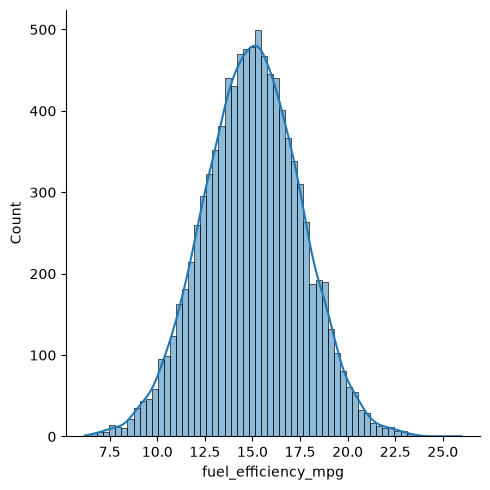

In [8]:
sns.displot(data=df_selected, x='fuel_efficiency_mpg', kde=True)

In [9]:
df_selected.isnull().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [10]:
df_selected.describe()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,9704.000000,8996.000000,9704.000000,9704.000000,9704.000000
mean,199.708368,149.657292,3001.280993,2011.484027,14.985243
std,49.455319,29.879555,497.894860,6.659808,2.556468
min,10.000000,37.000000,952.681761,2000.000000,6.200971
25%,170.000000,130.000000,2666.248985,2006.000000,13.267459
50%,200.000000,149.000000,2993.226296,2012.000000,15.006037
75%,230.000000,170.000000,3334.957039,2017.000000,16.707965
max,380.000000,271.000000,4739.077089,2023.000000,25.967222


### Validation framework    

In [11]:
rng = np.random.default_rng(42)
idx = rng.permutation(np.arange(df_selected.shape[0]))
idx

array([1425, 7185, 7477, ..., 4802, 5668, 5729], shape=(9704,))

In [12]:
n_val = int(df_selected.shape[0] * 0.2)
n_test = int(df_selected.shape[0] * 0.2)
n_train = df_selected.shape[0] - n_val - n_test

In [13]:
df_train = df_selected.iloc[idx[:n_train]]
df_val = df_selected.iloc[idx[n_train:n_train + n_val]]
df_test = df_selected.iloc[idx[n_train + n_val:]]

In [14]:
y_train = df_selected['fuel_efficiency_mpg'].iloc[idx[:n_train]]
y_val = df_selected['fuel_efficiency_mpg'].iloc[idx[n_train:n_train + n_val]]
y_test = df_selected['fuel_efficiency_mpg'].iloc[idx[n_train + n_val:]]

In [15]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [16]:
df_train.shape, df_val.shape, df_test.shape

((5824, 4), (1940, 4), (1940, 4))

### Train the model

In [17]:
def prepare_df_fill_0(X):
    X = X.copy()
    X = X.fillna(0)

    return X.values

In [18]:
def prepare_df_fill_avg(X):
    X = X.copy()
    X = X.fillna(X['horsepower'].mean())

    return X.values

In [19]:
X_train_fill_0 = prepare_df_fill_0(df_train)
X_train_fill_avg = prepare_df_fill_avg(df_train)

In [20]:
def train_linear_regression(X, y):
    X = np.column_stack([np.ones(X.shape[0]), X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)

    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]

In [21]:
w0_1, w_1 = train_linear_regression(X_train_fill_0, y_train)
w0_2, w_2 = train_linear_regression(X_train_fill_avg, y_train)

### Evaluate the model

In [22]:
def rmse(y, y_pred):
    mse = np.mean((y - y_pred)**2)
    return np.sqrt(mse)

In [23]:
X_val_fill_0 = prepare_df_fill_0(df_val)
y_pred_fill_0 = w0_1 + X_val_fill_0.dot(w_1)
round(rmse(y_val, y_pred_fill_0), 2)

np.float64(0.52)

In [24]:
X_val_fill_avg = prepare_df_fill_avg(df_val)
y_pred_fill_avg = w0_2 + X_val_fill_avg.dot(w_2)
round(rmse(y_val, y_pred_fill_avg), 2)

np.float64(0.47)

### Regularization

In [25]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]

In [26]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train_fill_0, y_train, r=r)
    X_val_fill_0 = prepare_df_fill_0(df_val)
    y_pred = w0 + X_val_fill_0.dot(w)
    score = rmse(y_val, y_pred)
    print(f"r: {r}, rmse: {score}")

r: 0, rmse: 0.5223249953485983
r: 0.01, rmse: 0.5225041637385578
r: 0.1, rmse: 0.5254236421418018
r: 1, rmse: 0.5295092676647489
r: 5, rmse: 0.5302324710445387
r: 10, rmse: 0.5303305566596935
r: 100, rmse: 0.5304204874117399


In [27]:
scores = []

for i in np.arange(10):
    rng = np.random.default_rng(seed=i)
    idx = rng.permutation(np.arange(df_selected.shape[0]))
    
    df_train = df_selected.iloc[idx[:n_train]]
    df_val = df_selected.iloc[idx[n_train:n_train + n_val]]
    df_test = df_selected.iloc[idx[n_train + n_val:]]

    y_train = df_selected['fuel_efficiency_mpg'].iloc[idx[:n_train]]
    y_val = df_selected['fuel_efficiency_mpg'].iloc[idx[n_train:n_train + n_val]]
    y_test = df_selected['fuel_efficiency_mpg'].iloc[idx[n_train + n_val:]]

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    X_train = prepare_df_fill_0(df_train)
    w0, w = train_linear_regression(X_train, y_train)

    X_val = prepare_df_fill_0(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    scores.append(score)
    print(f"seed: {i}, rmse: {score}")

seed: 0, rmse: 0.521301357719963
seed: 1, rmse: 0.5241858575886872
seed: 2, rmse: 0.5251710872664254
seed: 3, rmse: 0.524487117520067
seed: 4, rmse: 0.5257744007706344
seed: 5, rmse: 0.5257845195153993
seed: 6, rmse: 0.5196500141038807
seed: 7, rmse: 0.5105407559817257
seed: 8, rmse: 0.5204673488799809
seed: 9, rmse: 0.5323560299249768


In [28]:
round(np.std(scores), 3)

np.float64(0.005)

In [29]:
rng = np.random.default_rng(seed=9)
idx = rng.permutation(np.arange(df_selected.shape[0]))
    
df_train = df_selected.iloc[idx[:n_train]]
df_val = df_selected.iloc[idx[n_train:n_train + n_val]]
df_test = df_selected.iloc[idx[n_train + n_val:]]

y_train = df_selected['fuel_efficiency_mpg'].iloc[idx[:n_train]]
y_val = df_selected['fuel_efficiency_mpg'].iloc[idx[n_train:n_train + n_val]]
y_test = df_selected['fuel_efficiency_mpg'].iloc[idx[n_train + n_val:]]

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

X_train = prepare_df_fill_0(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.001)

X_val = prepare_df_fill_0(df_val)
y_pred = w0 + X_val.dot(w)
print(rmse(y_val, y_pred))

0.532389622336979
